# Connect Google Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import torch
print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Is CUDA available? True
GPU Name: NVIDIA L4


# Install **pytorch-tabnet, optuna**

In [ ]:
!pip install pytorch-tabnet optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 17.2 MB/s eta 0:00:00


# Important Libraries

In [ ]:
import optuna
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from pytorch_tabnet.metrics import Metric
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pytorch_tabnet.metrics import Metric
import joblib
import os
import gc

# Sentinel-2

## Data Loading

In [ ]:
save_dir = "/content/drive/MyDrive/Thesis/Trained_models/"
file_path = "/content/drive/MyDrive/Thesis/Train_data/s2_with_veg_data.csv"

print("Loading data...")
df = pd.read_csv(file_path)
print("Data is loaded")

print("\nData preparation...")

df1 = df.loc[df["age"] != 5].dropna()

df1.drop(columns=["age", "stock_per_ha", "basal_area", "poly_id", "S2_Date"], axis=1, inplace=True)

y = df1["height"].values
X = df1.drop(columns="height", axis=1).values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

print(f"\nDatasets are read! X_train shape: {X_train.shape}, X_test shape: {X_test.shape}, X_val shape: {X_val.shape}")

Loading data...
Data is loaded

Data preparation...

Datasets are read! X_train shape: (284286, 52), X_test shape: (50169, 52), X_val shape: (59022, 52)


### Cleaning RAM

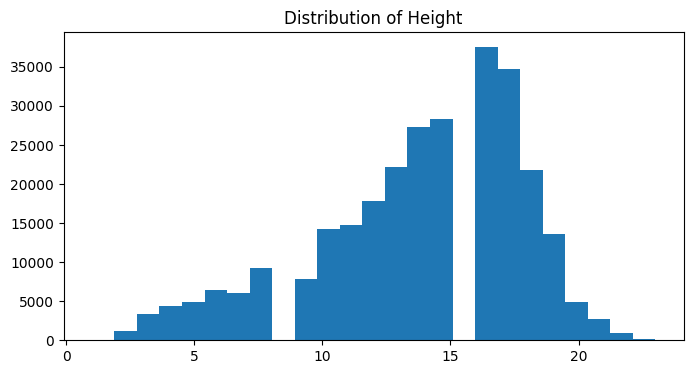

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(y_train, bins=25)
plt.title("Distribution of Height")
plt.show()

In [ ]:
import gc
del df, df1, X, y

gc.collect()

4302

##Bayesian Optimization

In [ ]:
X_train_np = X_train.values.astype(np.float32) if isinstance(X_train, pd.DataFrame) else X_train.astype(np.float32)
y_train_np = y_train.values.astype(np.float32).reshape(-1, 1) if isinstance(y_train, pd.Series) else y_train.astype(np.float32).reshape(-1, 1)

X_val_np = X_val.values.astype(np.float32) if isinstance(X_val, pd.DataFrame) else X_val.astype(np.float32)
y_val_np = y_val.values.astype(np.float32).reshape(-1, 1) if isinstance(y_val, pd.Series) else y_val.astype(np.float32).reshape(-1, 1)

X_test_np = X_test.values.astype(np.float32) if isinstance(X_test, pd.DataFrame) else X_test.astype(np.float32)
y_test_np = y_test.values.astype(np.float32).reshape(-1, 1) if isinstance(y_test, pd.Series) else y_test.astype(np.float32).reshape(-1, 1)

In [ ]:
def objective_standard_reg(trial):
    # Hyperparameter Space
    n_d = trial.suggest_int('n_d', 16, 64, step=16)
    n_a = n_d # Keep equal
    n_steps = trial.suggest_int('n_steps', 3, 7)
    gamma = trial.suggest_float('gamma', 1.0, 2.0)
    lambda_sparse = trial.suggest_float('lambda_sparse', 1e-5, 1e-2, log=True)
    learning_rate = trial.suggest_float('lr', 1e-3, 1e-1, log=True)

    # Initialize Model
    reg = TabNetRegressor(
        n_d=n_d,
        n_a=n_a,
        n_steps=n_steps,
        gamma=gamma,
        lambda_sparse=lambda_sparse,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=learning_rate),
        scheduler_params={"step_size":20, "gamma":0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type='entmax',
        verbose=0,
        device_name='cuda'
    )

    # Train Model (Using all data, passing validation set)
    reg.fit(
        X_train=X_train_np, y_train=y_train_np,
        eval_set=[(X_val_np, y_val_np)],
        eval_name=['valid'],
        eval_metric=['rmse'],
        max_epochs=100,
        patience=20,
        batch_size=4096,
        virtual_batch_size=512,
        num_workers= 12
    )

    # Evaluate
    preds = reg.predict(X_val_np)
    # Clip negatives so the tuner learns that negative predictions are penalized implicitly
    preds = np.clip(preds, 0, None)
    rmse = np.sqrt(mean_squared_error(y_val_np, preds))

    return rmse

print("\nStarting Optuna Optimization for Standard TabNet Height Model...")

study_std = optuna.create_study(direction='minimize')
# 50 trials is usually enough to find a great region!
study_std.optimize(objective_standard_reg, n_trials=50)

print("\nBest Parameters Found:")
for key, value in study_std.best_params.items():
    print(f"  {key}: {value}")

[I 2026-05-05 15:15:09,100] A new study created in memory with name: no-name-93408026-f0fd-4512-b181-8fd67a42c144



Starting Optuna Optimization for Standard TabNet Height Model...
Stop training because you reached max_epochs = 100 with best_epoch = 99 and best_valid_rmse = 3.11005


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-05 15:24:15,307] Trial 0 finished with value: 3.110049687322887 and parameters: {'n_d': 32, 'n_steps': 5, 'gamma': 1.6159644842999947, 'lambda_sparse': 0.0019378787162766264, 'lr': 0.0023448732730441415}. Best is trial 0 with value: 3.110049687322887.


Stop training because you reached max_epochs = 100 with best_epoch = 99 and best_valid_rmse = 3.48026


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-05 15:34:37,243] Trial 1 finished with value: 3.4802595390351865 and parameters: {'n_d': 16, 'n_steps': 6, 'gamma': 1.4589741932567224, 'lambda_sparse': 0.00852317017311569, 'lr': 0.0018712272955329283}. Best is trial 0 with value: 3.110049687322887.


...

Stop training because you reached max_epochs = 100 with best_epoch = 93 and best_valid_rmse = 2.98827


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-05 21:44:02,077] Trial 48 finished with value: 2.988269761007326 and parameters: {'n_d': 64, 'n_steps': 6, 'gamma': 1.7732555547355948, 'lambda_sparse': 0.003529388541510246, 'lr': 0.006439270898526142}. Best is trial 24 with value: 2.9739316993674287.


Stop training because you reached max_epochs = 100 with best_epoch = 98 and best_valid_rmse = 2.98943


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-05 21:55:15,992] Trial 49 finished with value: 2.989425779083244 and parameters: {'n_d': 64, 'n_steps': 7, 'gamma': 1.333675800874094, 'lambda_sparse': 0.0006985762502880888, 'lr': 0.005076246823316971}. Best is trial 24 with value: 2.9739316993674287.



Best Parameters Found:
  n_d: 48
  n_steps: 3
  gamma: 1.1484990857274557
  lambda_sparse: 2.203640606782299e-05
  lr: 0.032174279968699857


**Best Params**

In [ ]:
# Best Parameters Found:
#   n_d: 48
#   n_steps: 3
#   gamma: 1.1484990857274557
#   lambda_sparse: 2.203640606782299e-05
#   lr: 0.032174279968699857

# Alpha Earth Foundation + Sentinel-2


## Data Loading

In [ ]:
save_dir = "/content/drive/MyDrive/Thesis/Trained_models/"
file_path = "/content/drive/MyDrive/Thesis/Train_data/s2_aef_with_veg_data.csv"

print("Loading data...")
df = pd.read_csv(file_path)
print("Data is loaded")

print("\nData preparation...")

df1 = df.loc[df["age"] != 5].dropna()

df1.drop(columns=["age", "stock_per_ha", "basal_area", "poly_id", "S2_Date"], axis=1, inplace=True)

y = df1["height"].values
X = df1.drop(columns="height", axis=1).values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

print(f"\nDatasets are read! X_train shape: {X_train.shape}, X_test shape: {X_test.shape}, X_val shape: {X_val.shape}")

Loading data...
Data is loaded

Data preparation...

Datasets are read! X_train shape: (284117, 308), X_test shape: (50139, 308), X_val shape: (58987, 308)


### Cleaning RAM

In [ ]:
import gc
del df, df1, X, y

gc.collect()

0

## Bayesian Optimization

In [ ]:
X_train_np = X_train.values.astype(np.float32) if isinstance(X_train, pd.DataFrame) else X_train.astype(np.float32)
y_train_np = y_train.values.astype(np.float32).reshape(-1, 1) if isinstance(y_train, pd.Series) else y_train.astype(np.float32).reshape(-1, 1)

X_val_np = X_val.values.astype(np.float32) if isinstance(X_val, pd.DataFrame) else X_val.astype(np.float32)
y_val_np = y_val.values.astype(np.float32).reshape(-1, 1) if isinstance(y_val, pd.Series) else y_val.astype(np.float32).reshape(-1, 1)

X_test_np = X_test.values.astype(np.float32) if isinstance(X_test, pd.DataFrame) else X_test.astype(np.float32)
y_test_np = y_test.values.astype(np.float32).reshape(-1, 1) if isinstance(y_test, pd.Series) else y_test.astype(np.float32).reshape(-1, 1)

In [ ]:
def objective_standard_reg(trial):
    # Hyperparameter Space
    n_d = trial.suggest_int('n_d', 16, 64, step=16)
    n_a = n_d # Keep equal
    n_steps = trial.suggest_int('n_steps', 3, 7)
    gamma = trial.suggest_float('gamma', 1.0, 2.0)
    lambda_sparse = trial.suggest_float('lambda_sparse', 1e-5, 1e-2, log=True)
    learning_rate = trial.suggest_float('lr', 1e-3, 1e-1, log=True)

    # Initialize Model
    reg = TabNetRegressor(
        n_d=n_d,
        n_a=n_a,
        n_steps=n_steps,
        gamma=gamma,
        lambda_sparse=lambda_sparse,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=learning_rate),
        scheduler_params={"step_size":20, "gamma":0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type='entmax',
        verbose=0,
        device_name='cuda'
    )

    # Train Model (Using all data, passing validation set)
    reg.fit(
        X_train=X_train_np, y_train=y_train_np,
        eval_set=[(X_val_np, y_val_np)],
        eval_name=['valid'],
        eval_metric=['rmse'],
        max_epochs=100,
        patience=20,
        batch_size=4096,
        virtual_batch_size=512,
        num_workers= 12
    )

    # Evaluate
    preds = reg.predict(X_val_np)
    rmse = np.sqrt(mean_squared_error(y_val_np, preds))

    return rmse

print("\nStarting Optuna Optimization for Standard TabNet Height Model...")

study_std = optuna.create_study(direction='minimize')
# 50 trials is usually enough to find a great region!
study_std.optimize(objective_standard_reg, n_trials=50)

print("\nBest Parameters Found:")
for key, value in study_std.best_params.items():
    print(f"  {key}: {value}")

[I 2026-05-06 03:13:28,745] A new study created in memory with name: no-name-5a4abfd8-862e-4c34-9cfc-333131a1536c



Starting Optuna Optimization for Standard TabNet Height Model...
Stop training because you reached max_epochs = 100 with best_epoch = 94 and best_valid_rmse = 1.73728


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-06 03:20:52,384] Trial 0 finished with value: 1.7372771717141893 and parameters: {'n_d': 48, 'n_steps': 3, 'gamma': 1.4613675934412007, 'lambda_sparse': 0.00014181046524808563, 'lr': 0.06551557114473117}. Best is trial 0 with value: 1.7372771717141893.


Stop training because you reached max_epochs = 100 with best_epoch = 99 and best_valid_rmse = 2.43639


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-06 03:33:44,228] Trial 1 finished with value: 2.436394367354174 and parameters: {'n_d': 48, 'n_steps': 7, 'gamma': 1.110735731342495, 'lambda_sparse': 6.296327209606955e-05, 'lr': 0.004906268029378301}. Best is trial 0 with value: 1.7372771717141893.


...

Stop training because you reached max_epochs = 100 with best_epoch = 89 and best_valid_rmse = 1.48609


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-06 10:30:15,696] Trial 48 finished with value: 1.4860927079547739 and parameters: {'n_d': 48, 'n_steps': 3, 'gamma': 1.1551172233660476, 'lambda_sparse': 0.0013615325412730224, 'lr': 0.009879885480596068}. Best is trial 18 with value: 1.2863039034715635.


Stop training because you reached max_epochs = 100 with best_epoch = 95 and best_valid_rmse = 1.54086


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-06 10:40:28,897] Trial 49 finished with value: 1.5408607472769171 and parameters: {'n_d': 64, 'n_steps': 5, 'gamma': 1.2078496883490122, 'lambda_sparse': 0.0004203350363134412, 'lr': 0.03138560939010321}. Best is trial 18 with value: 1.2863039034715635.



Best Parameters Found:
  n_d: 64
  n_steps: 3
  gamma: 1.3761076912492625
  lambda_sparse: 0.0003332282653799267
  lr: 0.016220882600581313


**Best Params**

In [ ]:
# Best Parameters Found:
#   n_d: 64
#   n_steps: 3
#   gamma: 1.3761076912492625
#   lambda_sparse: 0.0003332282653799267
#   lr: 0.016220882600581313